# Objective
**Build and compare Scikit-learn preprocessing pipelines and evaluate two classification models.**

# Part A - Data Loading and Preprocessing with Scikit-learn

**Task 1 - Load and Understand the Dataset**
* Load hotel_bookings.csv. Use head(), shape, info(), describe(), and dtypes.
* Check the class distribution of is_canceled and use it as the target y.
* Create X from the remaining usable features. Identify numerical and categorical columns.

In [ ]:
import pandas as pd
import numpy as np

In [3]:
data = pd.read_csv('hotel_bookings.csv')
print(data.head(5))
print(data.shape)
print(data.info())
print(data.describe())
print(data.dtypes)

          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...    No Deposit   
1     

In [4]:
# class distribution of is_cancelled
print("\nClass Distribution:")
print(data["is_canceled"].value_counts())


Class Distribution:
is_canceled
0    75166
1    44224
Name: count, dtype: int64


In [5]:
# Target variable
y = data["is_canceled"]

# Remaining columns are input features
X = data.drop(columns=["is_canceled"])

In [6]:
# Identify numerical and categorical columns
numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("\nNumerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)


Numerical Columns:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical Columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


C:\Users\devan\AppData\Local\Temp\ipykernel_8856\2736801362.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(


**Task 2 - Missing Values, Leakage, and Outliers**
* Find the missing-value count and percentage for every column.
* Identify columns with very high missingness. Drop them only if justified and state the reason.
* Remove columns that directly reveal the final booking outcome, such as reservation_status and
reservation_status_date.
* Check selected numerical features for outliers using boxplots and/or the IQR method.
* Remove only clear/extreme outliers and report how many rows were removed.

In [7]:
# Missing value count
missing_count = data.isnull().sum()

print("\nMissing Values:")
print(missing_count)

# Missing value percentage
missing_percentage = (data.isnull().sum() / len(data)) * 100

print("\nMissing Value Percentage:")
print(missing_percentage)


Missing Values:
hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340

- children has 4 missing values, it is not very high so we don't need to remove it
- country has 488 missing values, it is higher than children but decision has to be made that we should remove it not based on its influence on other columns
- agent column has 16340 missing value, it is very much higher we need to remove this column because, it will not contribute anyway in model and only increase the computation. so we remove this column
- similar for company

In [8]:
df = data.drop(columns=["company", "agent"])

In [9]:
df = df.drop(columns=["reservation_status", "reservation_status_date"])

reservation status tells us whether booking is cancelled or not, if this is kept in data then classification model will get data and it will connect it directly to the output

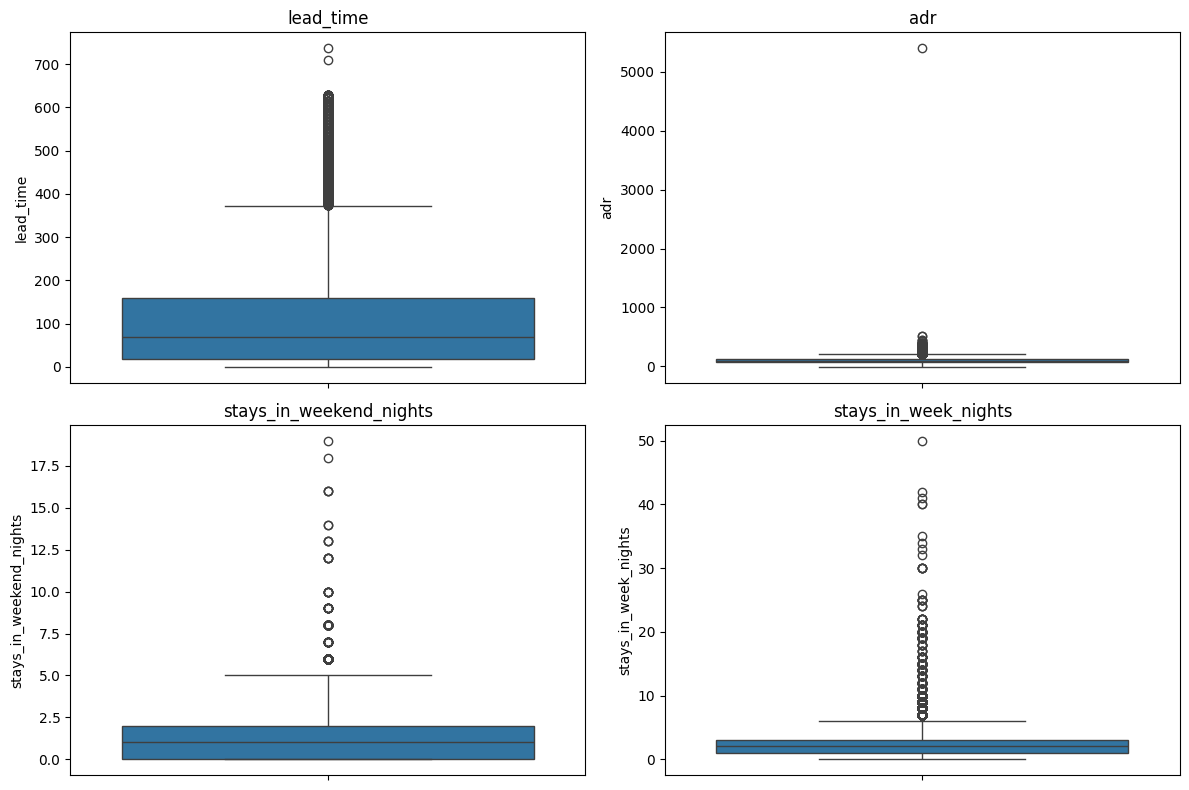

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select some numerical columns
outlier_columns = [
    "lead_time",
    "adr",
    "stays_in_weekend_nights",
    "stays_in_week_nights"
]

# Create boxplots
plt.figure(figsize=(12, 8))

for i, column in enumerate(outlier_columns):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(y=df[column])
    plt.title(column)

plt.tight_layout()
plt.show()

- What does lead_time mean?
- It is the number of days between: booking date → arrival date
- For example: A customer books a hotel 100 days before arriving → lead_time = 100.
- Some values are around 700+ days, which are unusually high compared with most bookings.
- Most bookings are made relatively close to the arrival date, but some bookings are made much earlier and appear as potential outliers.

- What does adr mean? ADR = Average Daily Rate
- It represents the average price per room per day.
- For example: ADR = 100 means approximately £100 per room per day.
- This graph has a very large outlier around 5400.
- Most values are concentrated near the bottom, while one or a few values are extremely high.
- This is why the box looks very compressed.
- The majority of ADR values are much smaller than the extreme value.
- So this column clearly deserves an outlier check.
- ADR contains extreme high values, with one value around 5400 that is far above the normal range.

- Most customers stay between approximately:
- 0–2 weekend nights
- The median is around 1 night.
- The upper whisker reaches approximately 5 nights.

- Most bookings have approximately 1–3 weekday nights.
- The median is around 2 nights.
- The upper whisker is around 6 nights.
- Most customers stay only a few weekday nights, but some bookings have unusually long stays.

The box plots show that all four numerical features contain potential outliers. Lead time has several unusually high booking periods, ADR contains an extreme high value, and both weekend and weekday stay durations have some unusually long stays. These outliers were therefore checked using the IQR method before preprocessing.

In [11]:
# IQR method for ADR
Q1 = df["adr"].quantile(0.25)
Q3 = df["adr"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("\nADR Outlier Information:")
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

# Count ADR outliers
adr_outliers = df[
    (df["adr"] < lower_bound) |
    (df["adr"] > upper_bound)
]

print("ADR outliers:", len(adr_outliers))

rows_before = len(df)

df = df[
    (df["adr"] >= 0) &
    (df["adr"] <= upper_bound)
]

rows_after = len(df)

print("Rows removed:", rows_before - rows_after)


ADR Outlier Information:
Q1: 69.29
Q3: 126.0
IQR: 56.709999999999994
Lower Bound: -15.774999999999991
Upper Bound: 211.065
ADR outliers: 3793
Rows removed: 3794


**Task 3 - Create Two Preprocessing Pipelines**
* Split the data using train_test_split(test_size=0.2, stratify=y, random_state=42). Use the same split for
all experiments.
* For numerical columns, use KNNImputer(n_neighbors=5) for missing values.
* For categorical columns, use SimpleImputer(strategy="most_frequent") and
OneHotEncoder(handle_unknown="ignore").
* Pipeline A: KNNImputer + StandardScaler for numerical features.
* Pipeline B: KNNImputer + MinMaxScaler for numerical features.
* Use ColumnTransformer and Pipeline so that preprocessing is fitted only on the training data.

In [12]:
# Target variable
y = df["is_canceled"]

# Remaining columns are input features
X = df.drop(columns=["is_canceled"])


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("\nTraining rows:", len(X_train))
print("Testing rows:", len(X_test))


Training rows: 92476
Testing rows: 23120


In [15]:
# for numerical
# Pipeline A:
# Missing values -> KNN Imputer
# Scaling -> StandardScaler

numerical_pipeline_A = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", StandardScaler())
])


# Pipeline B:
# Missing values -> KNN Imputer
# Scaling -> MinMaxScaler

numerical_pipeline_B = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", MinMaxScaler())
])


In [16]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [17]:
# Preprocessor for Pipeline A
preprocessor_A = ColumnTransformer([
    ("numerical", numerical_pipeline_A, numerical_columns),
    ("categorical", categorical_pipeline, categorical_columns)
])


# Preprocessor for Pipeline B
preprocessor_B = ColumnTransformer([
    ("numerical", numerical_pipeline_B, numerical_columns),
    ("categorical", categorical_pipeline, categorical_columns)
])